In [1]:
import tensorflow as tf

In [2]:
import keras

In [3]:
import pandas

In [4]:
import sklearn

In [5]:
import matplotlib

In [6]:
from keras.datasets  import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [7]:
print('x_train_shape', x_train.shape) # will print - 50000 (images), 32 (height in pixels),32 widthheight in pixels), 3 (pixels in depth - RGB colors)

x_train_shape (50000, 32, 32, 3)


In [8]:
print('y_train_shape', y_train.shape) # will tell that there is one number (corresponding to the label) for each of 50000 images

y_train_shape (50000, 1)


In [9]:
print(x_train[0]) # will print how computer visualizes image - not much helpful to humans. so we will use matplotlib to plot image later
print(f"dimensions of each image = {len(x_train[0])}x{len(x_train[0][0])}x{len(x_train[0][0][0])}")


[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
dimensions of each image = 32x32x3


the label is: [6]


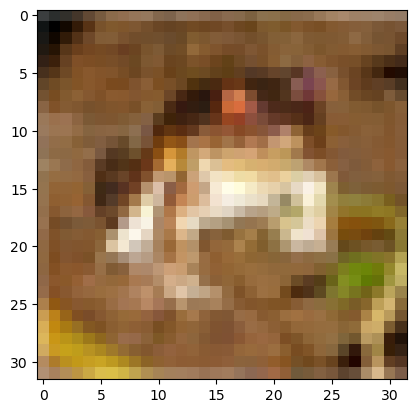

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

img = plt.imshow(x_train[0]) # the imge w2ill be shown very pixalated since it is tiny just 32x32 pixels
print('the label is:', y_train[0])

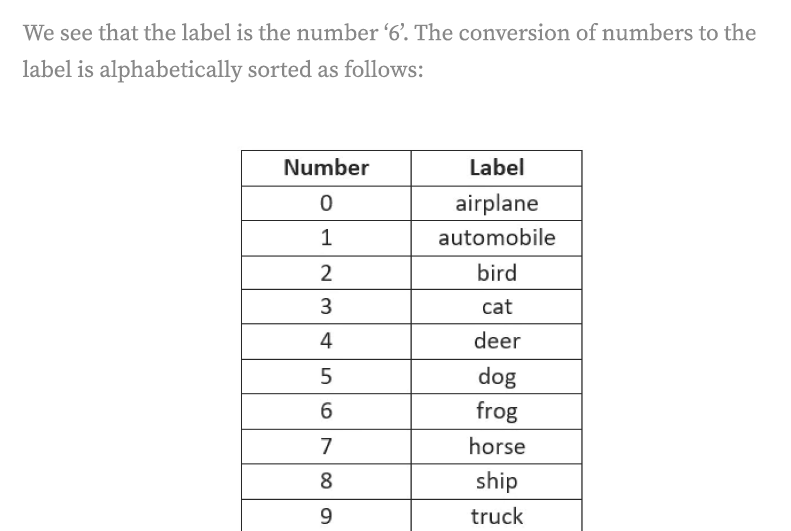

since we have to classify the 10 images we use 10 outputs fof NN using one hot encoding

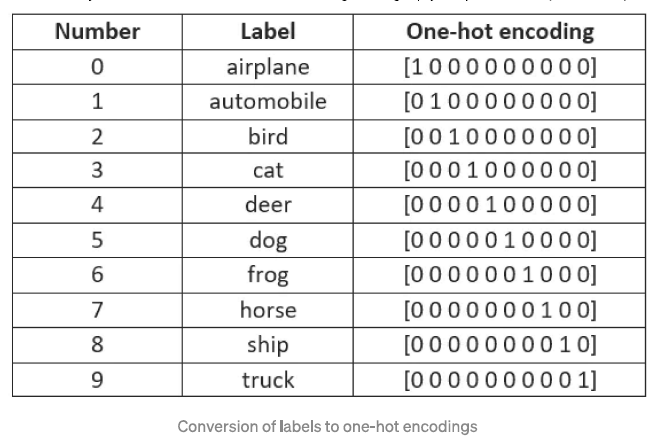

the label is: [9]


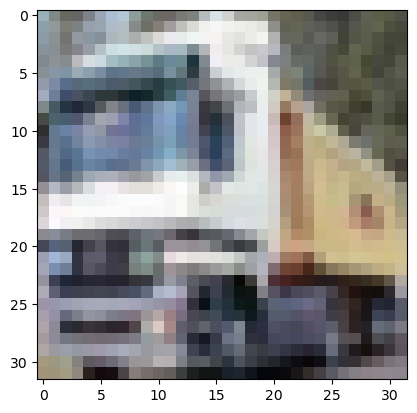

In [11]:

img = plt.imshow(x_train[1]) # the image will be shown very pixalated since it is tiny just 32x32 pixels
print('the label is:', y_train[1]) # is truck

In [12]:
import keras
y_train_one_hot = keras.utils.to_categorical(y_train,10)
y_test_one_hot = keras.utils.to_categorical(y_test,10)
print('The one hot label is:', y_train_one_hot[1])
# One-hot encoding ensures that machine learning does not assume that higher numbers are more important. For example, the value '8' is bigger than the value '1', but that does not make '8' more important than '1'.

The one hot label is: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [13]:
# lets normalize image sizes
# we let the RGB pixel values of image be between [0,1] by dividing with 255

x_train = x_train.astype('float32') # convert to datatype that can store decimals
x_test = x_test.astype('float32')
x_train = x_train / 255
x_test = x_test / 255
print('normalized x_train[1]=', x_train[1])

normalized x_train[1]= [[[0.6039216  0.69411767 0.73333335]
  [0.49411765 0.5372549  0.53333336]
  [0.4117647  0.40784314 0.37254903]
  ...
  [0.35686275 0.37254903 0.2784314 ]
  [0.34117648 0.3529412  0.2784314 ]
  [0.30980393 0.31764707 0.27450982]]

 [[0.54901963 0.627451   0.6627451 ]
  [0.5686275  0.6        0.6039216 ]
  [0.49019608 0.49019608 0.4627451 ]
  ...
  [0.3764706  0.3882353  0.30588236]
  [0.3019608  0.3137255  0.24313726]
  [0.2784314  0.28627452 0.23921569]]

 [[0.54901963 0.60784316 0.6431373 ]
  [0.54509807 0.57254905 0.58431375]
  [0.4509804  0.4509804  0.4392157 ]
  ...
  [0.30980393 0.32156864 0.2509804 ]
  [0.26666668 0.27450982 0.21568628]
  [0.2627451  0.27058825 0.21568628]]

 ...

 [[0.6862745  0.654902   0.6509804 ]
  [0.6117647  0.6039216  0.627451  ]
  [0.6039216  0.627451   0.6666667 ]
  ...
  [0.16470589 0.13333334 0.14117648]
  [0.23921569 0.20784314 0.22352941]
  [0.3647059  0.3254902  0.35686275]]

 [[0.64705884 0.6039216  0.5019608 ]
  [0.6117647  

Setting up CNN Architecture

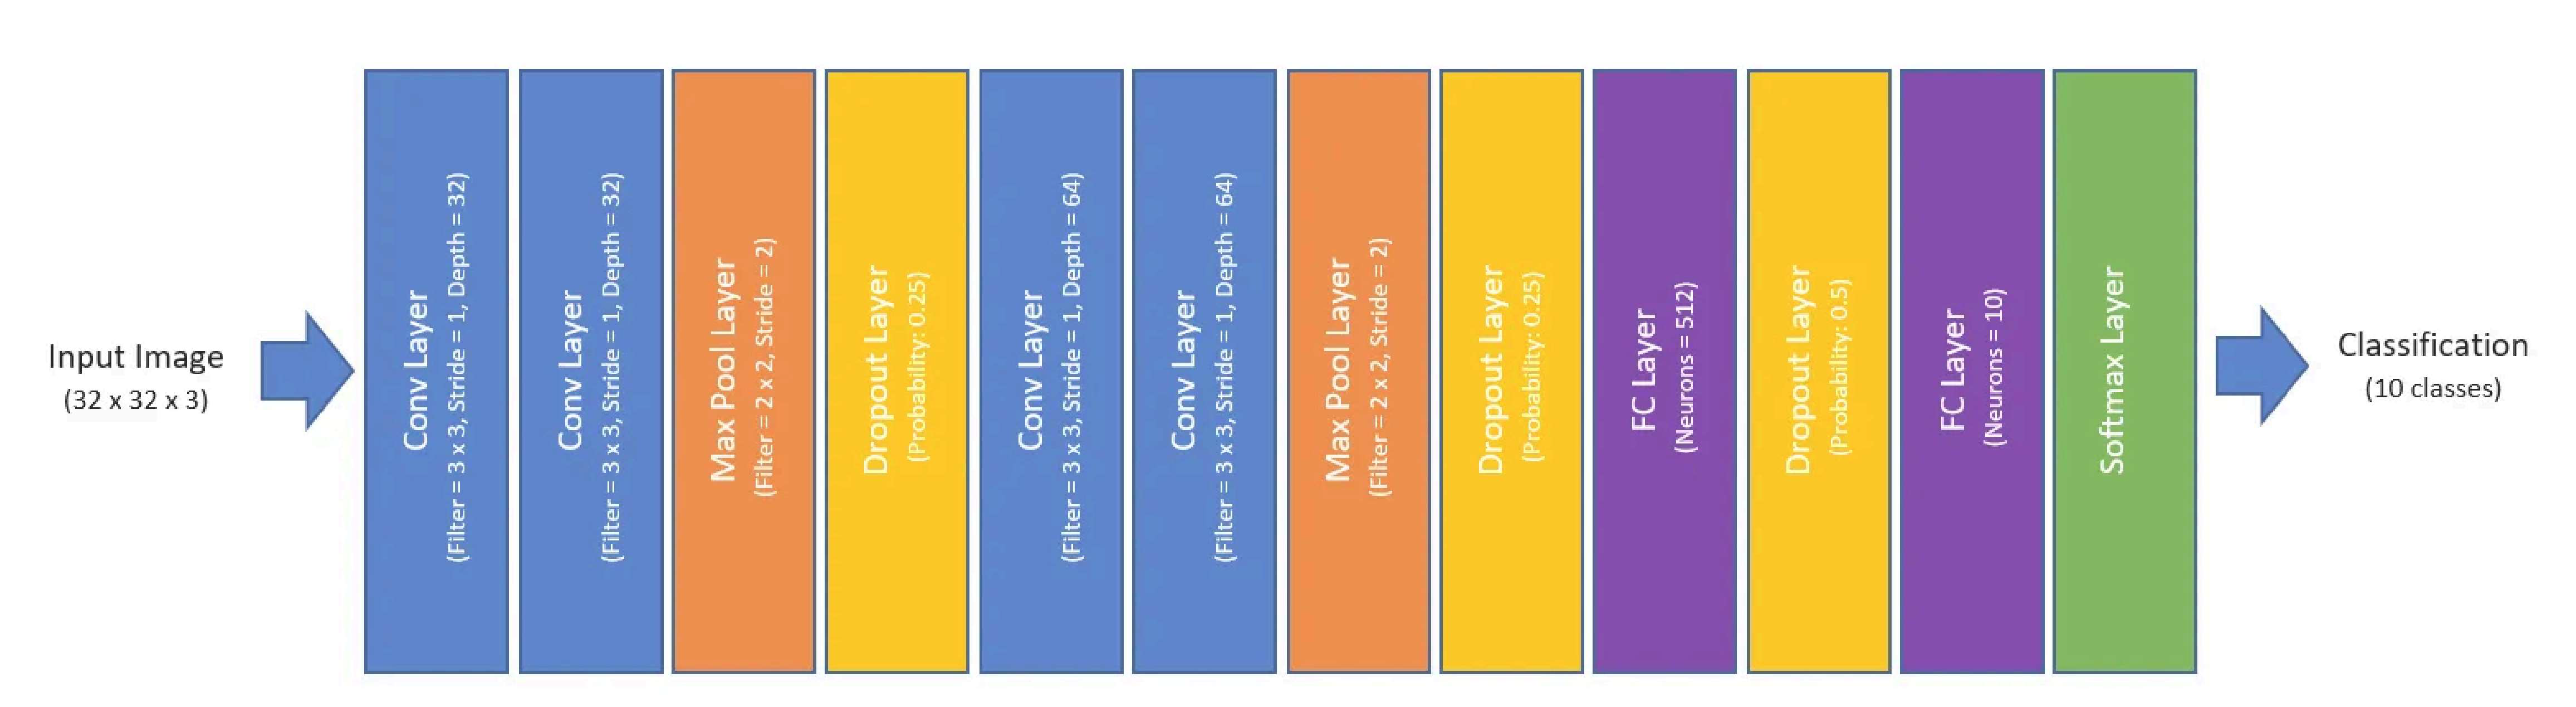

Since we are using 3x3 filter and the image is 32x32 we will have to pad one pixel so it will be 33x33 (so 3 times 11 = 33). We will zero=pad our layers for now

The output layer is softmax layer, which justtransforms output of previous layer into probability distributions. For all other layers we use ReLU activation. We'll use Keras sequential model where each layer of CNN is just 1 line of code.

In [14]:
from keras.models import Sequential
from keras.layers import  Dense, Dropout, Flatten, Conv2D, MaxPooling2D

model = Sequential() # create empty model then add one layer of CNN in each step

# convolution layer with 32 depth, filter size 3x3, stride size 1 (in both dimensions), and depth 32
model.add(Conv2D(32, (3,3), activation='relu',padding='same',input_shape=(32,32,3)))

# other layers do not need to specify input shape since it is inferred from output of previous layers
model.add(Conv2D(32, (3,3), activation='relu',padding='same'))

# maxpooling layer with pool size 2x2 and stride 2 (in both dimentions) which deafults to pool size
model.add(MaxPooling2D(pool_size=(2, 2)))

# Dropout layer with 25% random neurons dropped in each training
model.add(Dropout(0.25))

# next 4 layers are similar to first 4 layers except the depth is 64 instead of 32 (i.e., more features are discovered)
model.add(Conv2D(64, (3,3), activation='relu',padding='same'))
model.add(Conv2D(64, (3,3), activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# flatten layer
model.add(Flatten())

# dense layer of 512 neurons with relu activation
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.25))

# output layer with 10 neurons and softmax activation
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        36928     
                                                        

In [15]:
# compile the model using categorical cross entropy (loss function) + Adam optimizer (stochastic gradient descent)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [16]:
# train model with batch size 32 and 20 epochs

hist = model.fit(x_train, y_train_one_hot, 
           batch_size=32, epochs=20, 
           validation_split=0.2)

Epoch 1/20
1250/1250 [==============================] - 95s 75ms/step - loss: 1.5025 - accuracy: 0.4499 - val_loss: 1.0926 - val_accuracy: 0.6095
Epoch 2/20
1250/1250 [==============================] - 96s 77ms/step - loss: 1.0556 - accuracy: 0.6243 - val_loss: 0.9538 - val_accuracy: 0.6666
Epoch 3/20
1250/1250 [==============================] - 96s 77ms/step - loss: 0.8663 - accuracy: 0.6964 - val_loss: 0.7799 - val_accuracy: 0.7303
Epoch 4/20
1250/1250 [==============================] - 103s 82ms/step - loss: 0.7616 - accuracy: 0.7314 - val_loss: 0.7309 - val_accuracy: 0.7497
Epoch 5/20
1250/1250 [==============================] - 99s 79ms/step - loss: 0.6784 - accuracy: 0.7627 - val_loss: 0.7893 - val_accuracy: 0.7321
Epoch 6/20
1250/1250 [==============================] - 101s 81ms/step - loss: 0.6048 - accuracy: 0.7874 - val_loss: 0.7051 - val_accuracy: 0.7599
Epoch 7/20
1250/1250 [==============================] - 102s 82ms/step - loss: 0.5419 - accuracy: 0.8087 - val_loss: 0.689

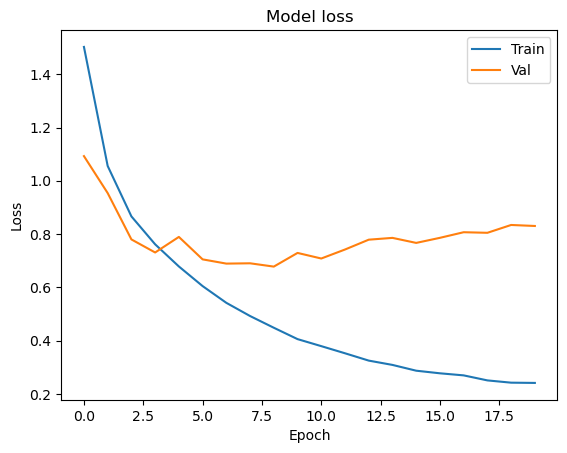

In [17]:
# visualize the model training anbd validation loss over the number of epochs 
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

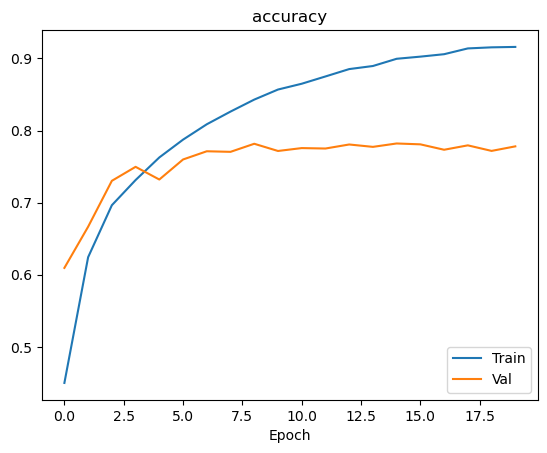

In [20]:
# visualize accuracy
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('accuracy')
plt.xlabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Val'], loc='lower right')
plt.show()


In [21]:
# you can try changing architecture or increasing number of epochs to see if you can get better val accuracy
# for now we go ahead with established accuracy and evaluate it on test dataset
model.evaluate(x_test, y_test_one_hot)[1]

313/313 [==============================] - 6s 19ms/step - loss: 0.8819 - accuracy: 0.7619


0.761900007724762

In [22]:
# we got 76% accuracy .. not the 94% human accuracy yet
# we will save the model so it can be reused later

model.save('12_18_2024_cifar10_model.h5')

# if you want to use the model use the following code
# from keras.models import load_model
# model = load_model('12_18_2024_cifar10_model.h5')

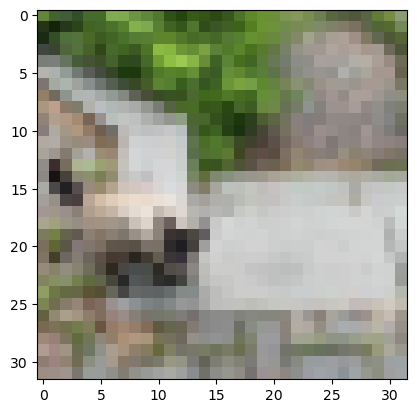

In [24]:
# testing with your own images
# downloaded 2 images of cats on porch from internet

img8 = plt.imread("cat_on_porch_8.jpg")

# to resize this image to 32x32 we download and use scikit-image package through anaconda 

from skimage.transform import resize
img8_resized = resize(img8, (32,32,3))
img = plt.imshow(img8_resized)
# note - resized image will already have pixel values scaled between 0 and 1, so we need not apply transform



In [25]:
import numpy as np
# model.predict expects 4D array (the 4th dimension is the number of training examples)
probabilities = model.predict(np.array([img8_resized,]))
print('probabilities =', probabilities)
  

1/1 [==============================] - 0s 244ms/step
probabilities = [[4.0230532e-03 2.9431321e-04 6.2002063e-01 2.9329382e-02 3.2924932e-01
  1.0452286e-02 1.1368355e-03 1.7523962e-03 1.8086405e-03 1.9331716e-03]]


In [26]:
number_to_class = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
index = np.argsort(probabilities[0,:])
print("Most likely class:", number_to_class[index[9]], "-- Probability:", probabilities[0, index[9]])
print("Second most likely class:", number_to_class[index[8]], "-- Probability:", probabilities[0, index[8]])
print("Third most likely class:", number_to_class[index[7]], "-- Probability:", probabilities[0, index[7]])
print("Fourth most likely class:", number_to_class[index[6]], "-- Probability:", probabilities[0, index[6]])

Most likely class: bird -- Probability: 0.6200206
Second most likely class: deer -- Probability: 0.32924932
Third most likely class: cat -- Probability: 0.029329382
Fourth most likely class: dog -- Probability: 0.010452286


In [27]:
img_cat_10 = plt.imread("cat_10.jpg")

# to resize this image to 32x32 we download and use scikit-image package through anaconda 

from skimage.transform import resize
img_cat_10_resized = resize(img_cat_10, (32,32,3))
probabilities = model.predict(np.array([img_cat_10_resized,]))
print('probabilities =', probabilities)
index = np.argsort(probabilities[0,:])
print("Most likely class:", number_to_class[index[9]], "-- Probability:", probabilities[0, index[9]])
print("Second most likely class:", number_to_class[index[8]], "-- Probability:", probabilities[0, index[8]])
print("Third most likely class:", number_to_class[index[7]], "-- Probability:", probabilities[0, index[7]])
print("Fourth most likely class:", number_to_class[index[6]], "-- Probability:", probabilities[0, index[6]])

1/1 [==============================] - 0s 21ms/step
probabilities = [[2.1398517e-03 2.7805170e-06 9.3397786e-05 4.0498849e-02 5.2584417e-02
  3.2790933e-02 3.5720917e-09 1.5210515e-01 7.1969807e-01 8.6478729e-05]]
Most likely class: ship -- Probability: 0.7196981
Second most likely class: horse -- Probability: 0.15210515
Third most likely class: deer -- Probability: 0.052584417
Fourth most likely class: cat -- Probability: 0.04049885
